# Example of usage of open_save code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [1]:
R = 1.
r = 0.2

NGSOLVE = True

lc = 0.3

if NGSOLVE:
    from cases.open_space.ngsolve_geometries import CleanCircle, AnularDomain, Regions
    mesh = AnularDomain(R=R, r=r, verbosity=0, lc=lc)
    #mesh = CleanCircle(R=R, verbosity=0, lc=lc)
else:
    raise NotImplementedError
    from cases.open_space.gmsh_geometries import CleanWaveguide, WaveguideRegions
    mesh = CleanWaveguide(R=R, H=H, verbose=True, lc=lc)


In [2]:
mesh.n_triangles

118

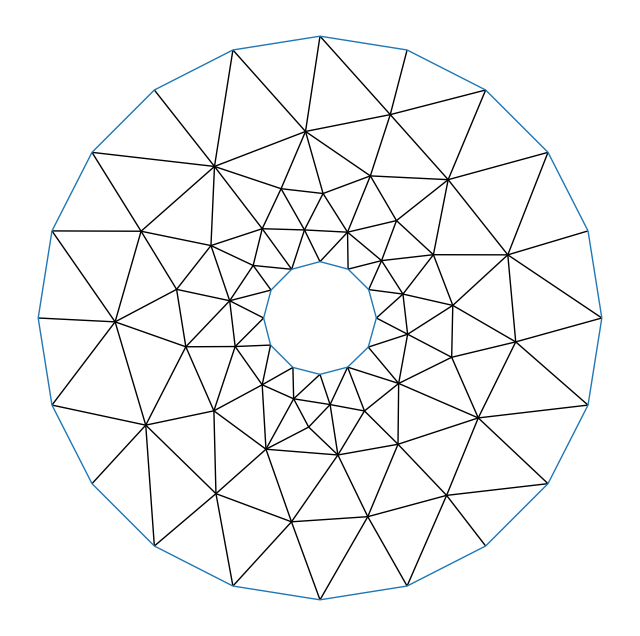

In [3]:
from cases.open_space.plot import plot_openspace
plot_openspace(mesh)

In [4]:
list(Regions)

[<Regions.OMEGA: 'Omega'>,
 <Regions.SIGMA: 'Sigma'>,
 <Regions.d_Omega: 'd_Omega'>]

In [5]:
mesh.curve_region(Regions.SIGMA, radius=R)
mesh.curve_region(Regions.d_Omega, radius=r)


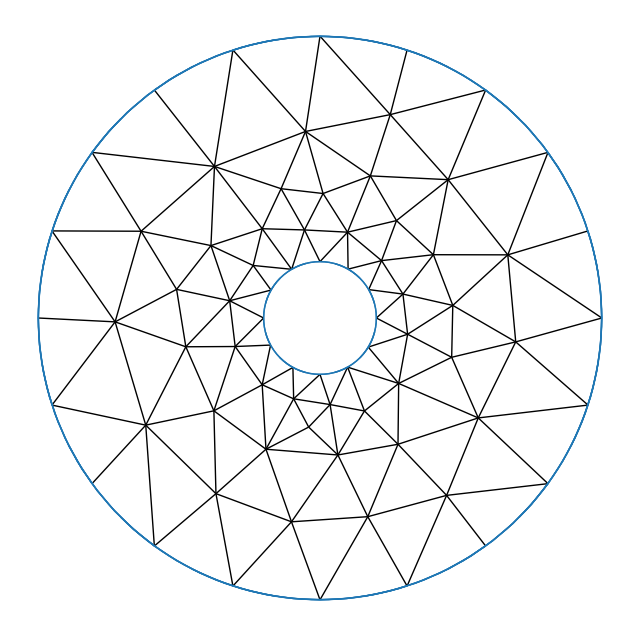

In [6]:
plot_openspace(mesh)

To that regions we can apply different boundary conditions. In our case we will set a radiant boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [7]:
from trefftz.dg.boundary_conditions import NtDBC, DirichletBC

In [8]:
import numpy as np
data = {"d_inc": np.array([-1., 0.])}
boundary_conditions = {Regions.SIGMA: NtDBC(truncating_radius=R, data=None), Regions.d_Omega: DirichletBC(data=data)}
#boundary_conditions = {Regions.SIGMA: DirichletBC(data=data),}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [9]:
from trefftz.dg.serial_fluxes import UltraWeakFlux, DirichletFlux


as well as specific ones (for a circular NtD map):

In [10]:
from cases.open_space.kernels import NtDLocal_circle, NtDNonLocal_circle

Now the numerics (the configuration of kernels) is almost a dictionary:

In [11]:
from trefftz.dg.assemblers import SerialNumerics
NtD_modes = 5
a = 0.5
b = 0.5
d1 = 0.5
d2 = 0.5
numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
                          local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data), NtDBC: NtDLocal_circle(R=R, d_2=d2, data=None)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal_circle(d_2=d2, NtD_modes=5, data = None)})

We should also choose a local basis

In [ ]:
from trefftz.dg.basis import LinearlySpacedBasis
k = 8.0
Ntheta = 3
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, k=k, N_theta=Ntheta)

and an assembler:

In [13]:
basis.N_DOF

1298

In [14]:
from trefftz.dg.assemblers import SerialAssembler

assembler = SerialAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

In [15]:
assembler._regions_RHS_term

[<Regions.d_Omega: 'd_Omega'>]

so we can set the problem:

In [16]:
from trefftz.problem import Problem
P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=True)

In [17]:
A = P.assemble_LHS()

KeyboardInterrupt: 

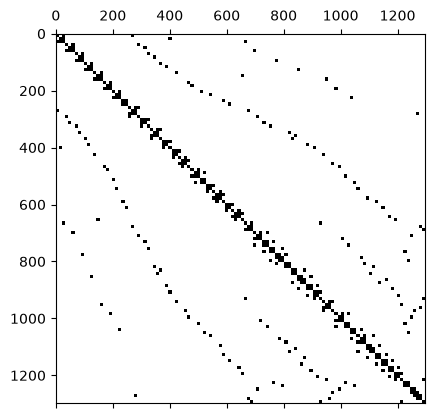

In [ ]:
import matplotlib.pyplot as plt 
plt.spy(A.toarray())

In [23]:
b = P.assemble_RHS()

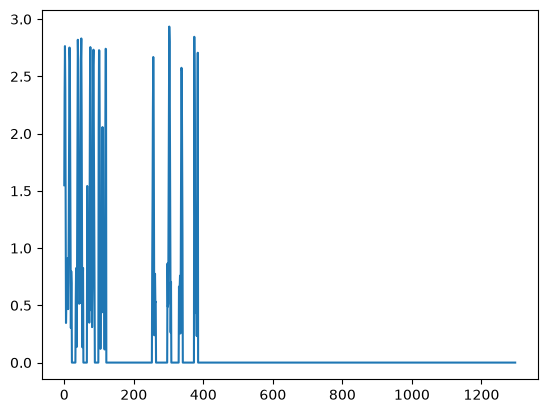

In [24]:
import numpy as np 
plt.plot(np.abs(b))

In [25]:
P.solve()

In [26]:
P.u_h.coefficients.reshape((-1,Ntheta))

array([[  273788.72536146+7.55356736e+02j,
         -176103.41807854-1.96626543e+05j,
           86591.46988627+2.21334211e+05j, ...,
           88481.44946718+8.35871083e+04j,
          -56375.7262479 -1.74040464e+05j,
         -130715.28202174+2.06142539e+05j],
       [ -284466.57000904+2.70020723e+05j,
          508252.68082742+8.66930930e+04j,
         -281558.79114682-4.14026627e+05j, ...,
          -16725.89331914+5.03954371e+03j,
           31190.69719731+9.57320672e+04j,
           18607.26952447-2.23205577e+05j],
       [ 1519007.65652997+3.15048654e+05j,
         -202285.25726569-1.34039697e+06j,
         -698045.86315903+7.40401155e+05j, ...,
          734247.4326424 +1.09977487e+06j,
         -440624.54006867-1.43807914e+06j,
         -852900.22421013+1.34214398e+06j],
       ...,
       [ 1565254.08093516-9.09142541e+05j,
         -341873.72604548-2.10429621e+06j,
        -2325890.2256731 -5.48110542e+05j, ...,
         -156082.48491154+2.23628760e+05j,
         -369893.41

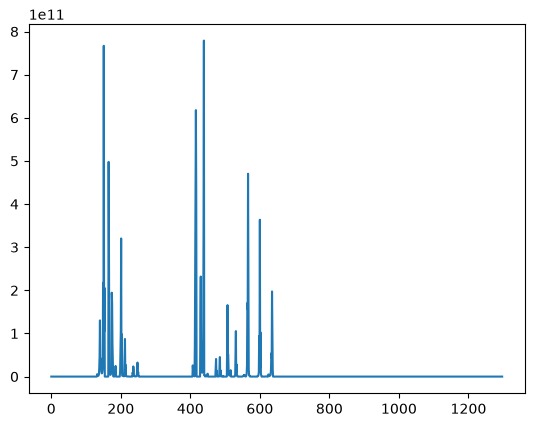

In [27]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

In [28]:
import numpy as np
N = 200
rs = np.linspace(r, R, N)
#rs = np.linspace(0, R, N)

theta = np.linspace(0, 2*np.pi, N)
Rs, Theta = np.meshgrid(rs, theta)
X = Rs*np.cos(Theta)
Y = Rs*np.sin(Theta)
x = X.ravel()
y = Y.ravel() 
z = P.u_h(x, y)

(np.float64(-1.09986915899354),
 np.float64(1.100062304173604),
 np.float64(-1.099965731583572),
 np.float64(1.099965731583572))

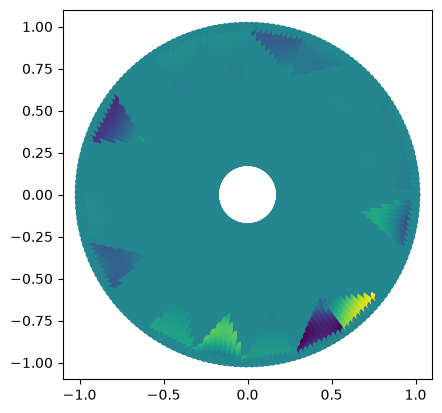

In [29]:
import matplotlib.pyplot as plt
plt.scatter(x,y,c=np.real(z),cmap="viridis")
plt.axis("square")